# Phase 1 (VAE variant): does a real VAE fix the flat latent space?

The plain deterministic autoencoder in `phase1_mtand_reconstruction.ipynb`
got a linear-probe R² of only ~0.33-0.44 for recovering `period` from its
unsupervised latent, and the (properly standardized, see below) t-SNE/UMAP
plots showed only a moderate gradient, not clean separation.

This notebook was prompted directly by a comparison notebook shared
during development, which used the *actual* VAE version of mTAND's
encoder-decoder (`enc_mtan_rnn`/`dec_mtan_rnn` with mean/logvar +
reparameterization + KL-to-standard-normal, `latent_dim=64`,
`embed_time=128`, ~5000 training iterations) and got a visibly better
organized latent space. Candidate explanations worth separating: (a) the
VAE's KL regularization itself (pushes the aggregate posterior toward an
isotropic Gaussian, which tends to produce smoother, more separable
geometry than an unregularized bottleneck), (b) much larger latent
capacity, (c) far more training, (d) that notebook's data had far lower
observation noise (`std=0.01` vs our `0.15`), which makes `period`
intrinsically easier to recover independent of architecture.

This notebook tests (a) and (b) directly against our own data (same
noise level, so that variable stays controlled), without trying to match
their full 5000-iteration training budget.

In [1]:
import os, sys, math, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
import umap

from src.data.toy_sine import ToySineDataset, collate_toy_sine
from src.mtand.model import MTANReconEncoderVAE, MTANReconDecoderProbabilistic

%matplotlib inline
SEED = 0
T_MAX = 20.0
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Model: VAE encoder + probabilistic (heteroscedastic) decoder

Two changes from the plain autoencoder notebook:

- **`MTANReconEncoderVAE`**: outputs `(mean, log-variance)` per reference
  point instead of a single deterministic vector, sampled via the
  reparameterization trick and regularized toward a standard normal with a
  KL term -- the actual VAE ELBO, not just reconstruction MSE.
- **`MTANReconDecoderProbabilistic`**: outputs `(mean, log-variance)` per
  query time instead of a point estimate, trained with Gaussian NLL using
  its *own* learned variance (not a fixed noise level). This also gives us
  genuine predictive uncertainty bands, which plain mTAND doesn't provide
  (its official VAE variant only puts a distribution over the encoder's
  latent, not over decoder predictions -- see the discussion in the other
  notebook).

`latent_dim=64` and `embed_time=64` here, vs. `latent_dim=8`,
`embed_time=32` in the plain autoencoder -- a compromise between our
original scale and the shared notebook's `64`/`128`, chosen to keep a
single training run tractable on CPU.

In [2]:
NUM_REF = 32
NHIDDEN = 32
EMBED_TIME = 64
LATENT_DIM = 64
BATCH_SIZE = 64
EPOCHS = 75
LR = 1e-3
KL_WARMUP_EPOCHS = 10
SNAPSHOT_EPOCHS = [0, 2, 5, 10, 20, 40, EPOCHS - 1]
SNAPSHOT_SERIES_IDX = [3, 7]

full_ds = ToySineDataset(n_series=5000, seed=SEED, t_max=T_MAX)
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [4500, 500], generator=torch.Generator().manual_seed(SEED))

def collate(batch):
    return collate_toy_sine(batch, t_max=T_MAX)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

query = torch.linspace(0, 1, NUM_REF)
encoder = MTANReconEncoderVAE(input_dim=1, query=query, latent_dim=LATENT_DIM, nhidden=NHIDDEN,
                               embed_time=EMBED_TIME, num_heads=1, learn_emb=True)
decoder = MTANReconDecoderProbabilistic(input_dim=1, query=query, latent_dim=LATENT_DIM, nhidden=NHIDDEN,
                                         embed_time=EMBED_TIME, num_heads=1, learn_emb=True)
params = list(encoder.parameters()) + list(decoder.parameters())
opt = torch.optim.Adam(params, lr=LR)

def elbo_loss(mean, logvar_obs, y, mask, z_mean, z_logvar, kl_coef):
    nll = 0.5 * (logvar_obs + (y - mean) ** 2 / torch.exp(logvar_obs) + math.log(2 * math.pi))
    nll = (nll * mask).sum() / mask.sum()
    kl = (-0.5 * (1 + z_logvar - z_mean.pow(2) - z_logvar.exp())).sum(-1).mean()
    return nll + kl_coef * kl, nll, kl

def evaluate(loader):
    encoder.eval(); decoder.eval()
    total_sq_err, total_mask = 0.0, 0.0
    with torch.no_grad():
        for x, t, period in loader:
            y, mask = x[:, :, 0], x[:, :, 1]
            z_mean, z_logvar, _ = encoder(x, t)
            mean, logvar_obs, _ = decoder(z_mean, t)
            total_sq_err += ((mean - y) ** 2 * mask).sum().item()
            total_mask += mask.sum().item()
    return total_sq_err / total_mask

## 2. Train, capturing reconstruction snapshots along the way

Snapshots for two fixed validation series are captured at several epochs
during the *actual* training run (not a separate replay), so what we plot
afterward is the real training trajectory.

In [3]:
def take_snapshot(dense_t):
    encoder.eval(); decoder.eval()
    snaps = {}
    with torch.no_grad():
        for idx in SNAPSHOT_SERIES_IDX:
            xi, yi, pi = val_ds.dataset[val_ds.indices[idx]]
            xb, tb, _ = collate_toy_sine([(xi, yi, pi)], t_max=T_MAX)
            z_mean, _, _ = encoder(xb, tb)
            dmean, dlogvar, _ = decoder(z_mean, dense_t)
            snaps[idx] = (dmean[0].numpy().copy(), torch.exp(0.5 * dlogvar)[0].numpy().copy())
    return snaps

dense_t = torch.linspace(0, 1, 300).unsqueeze(0)
snapshot_series = {}
for idx in SNAPSHOT_SERIES_IDX:
    xi, yi, pi = val_ds.dataset[val_ds.indices[idx]]
    snapshot_series[idx] = (xi.numpy(), yi.numpy(), float(pi))

all_snapshots = {-1: take_snapshot(dense_t)}

t_start = time.time()
for epoch in range(EPOCHS):
    encoder.train(); decoder.train()
    kl_coef = min(1.0, epoch / KL_WARMUP_EPOCHS)
    epoch_nll, epoch_kl, n = 0.0, 0.0, 0
    for x, t, period in train_loader:
        y, mask = x[:, :, 0], x[:, :, 1]
        opt.zero_grad()
        z_mean, z_logvar, _ = encoder(x, t)
        z = encoder.reparameterize(z_mean, z_logvar)
        mean, logvar_obs, _ = decoder(z, t)
        loss, nll, kl = elbo_loss(mean, logvar_obs, y, mask, z_mean, z_logvar, kl_coef)
        loss.backward()
        opt.step()
        epoch_nll += nll.item() * x.size(0)
        epoch_kl += kl.item() * x.size(0)
        n += x.size(0)
    if epoch in SNAPSHOT_EPOCHS:
        all_snapshots[epoch] = take_snapshot(dense_t)
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        val_mse = evaluate(val_loader)
        print(f'epoch {epoch:3d}  kl_coef={kl_coef:.2f}  nll={epoch_nll/n:.4f}  '
              f'kl={epoch_kl/n:.4f}  val_mse={val_mse:.4f}  elapsed={time.time()-t_start:.0f}s')

epoch   0  kl_coef=0.00  nll=1.0688  kl=3.3999  val_mse=0.4493  elapsed=7s


epoch  10  kl_coef=1.00  nll=1.0233  kl=0.0360  val_mse=0.4232  elapsed=77s


epoch  20  kl_coef=1.00  nll=0.9951  kl=0.0548  val_mse=0.3953  elapsed=147s


epoch  30  kl_coef=1.00  nll=0.9169  kl=0.0951  val_mse=0.3440  elapsed=220s


epoch  40  kl_coef=1.00  nll=0.8484  kl=0.1243  val_mse=0.3144  elapsed=294s


epoch  50  kl_coef=1.00  nll=0.7999  kl=0.1403  val_mse=0.3090  elapsed=363s


epoch  60  kl_coef=1.00  nll=0.7685  kl=0.1555  val_mse=0.2843  elapsed=431s


epoch  70  kl_coef=1.00  nll=0.7336  kl=0.1656  val_mse=0.2934  elapsed=502s


epoch  74  kl_coef=1.00  nll=0.7284  kl=0.1690  val_mse=0.2729  elapsed=532s


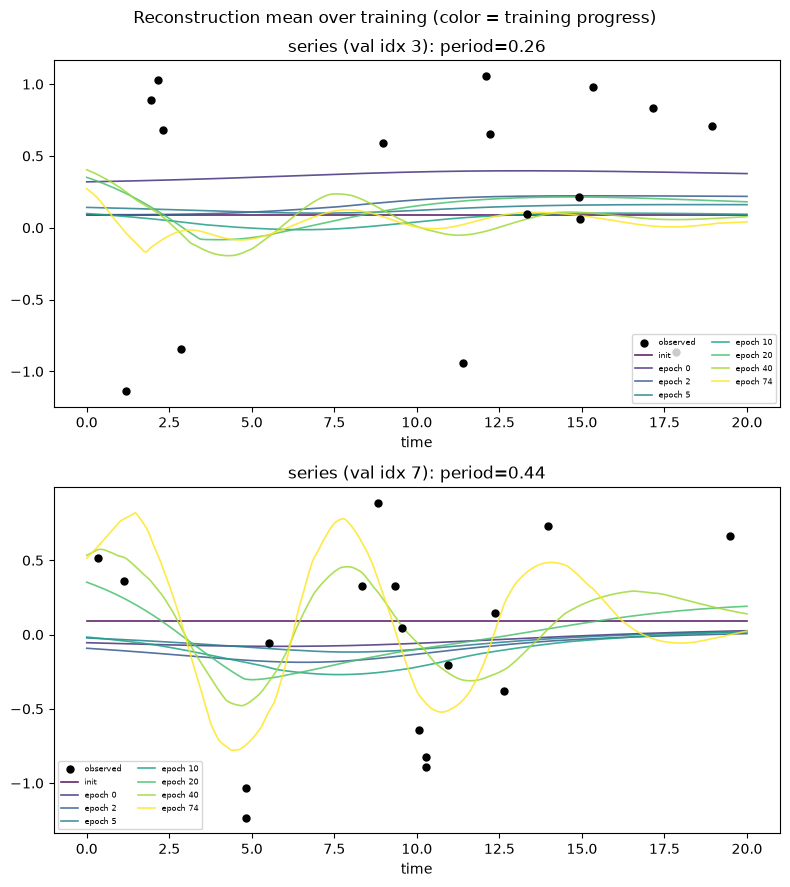

In [4]:
fig, axes = plt.subplots(len(SNAPSHOT_SERIES_IDX), 1, figsize=(8, 4.5 * len(SNAPSHOT_SERIES_IDX)))
cmap = plt.cm.viridis
all_ep_keys = sorted(all_snapshots.keys())
for row, idx in enumerate(SNAPSHOT_SERIES_IDX):
    ax = axes[row]
    x_np, y_np, period_val = snapshot_series[idx]
    ax.scatter(x_np, y_np, c='k', s=25, zorder=5, label='observed')
    for i, ep in enumerate(all_ep_keys):
        mean_snap, _ = all_snapshots[ep][idx]
        color = cmap(i / (len(all_ep_keys) - 1))
        label = 'init' if ep == -1 else f'epoch {ep}'
        ax.plot(dense_t[0].numpy() * T_MAX, mean_snap, color=color, alpha=0.85, linewidth=1.2, label=label)
    ax.set_title(f'series (val idx {idx}): period={period_val:.2f}')
    ax.set_xlabel('time')
    ax.legend(fontsize=6, ncol=2)
fig.suptitle('Reconstruction mean over training (color = training progress)')
fig.tight_layout()

**Read this alongside the point-estimate MSE reported below.** For the
`period=0.26` series, the mean curve stays close to flat throughout
training -- the true signal completes many cycles across the domain, and
rather than overfitting to noise trying to chase it, the model converges
toward hedging near the mean. That's discussed further in Section 4.

## 3. Latent space: does the VAE actually fix the separation?

Same procedure as the other notebook (mean-pool the per-reference-point
latent, standardize, then PCA/t-SNE/UMAP) but on this VAE's posterior
mean, and using the **same 250/250 train/test probe split logic** so the
R² is directly comparable to the plain autoencoder's ~0.33-0.44.

Linear probe: corr=0.866  R^2=0.724  (plain deterministic AE was ~0.33-0.44 R^2)


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_13041/3245881494.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


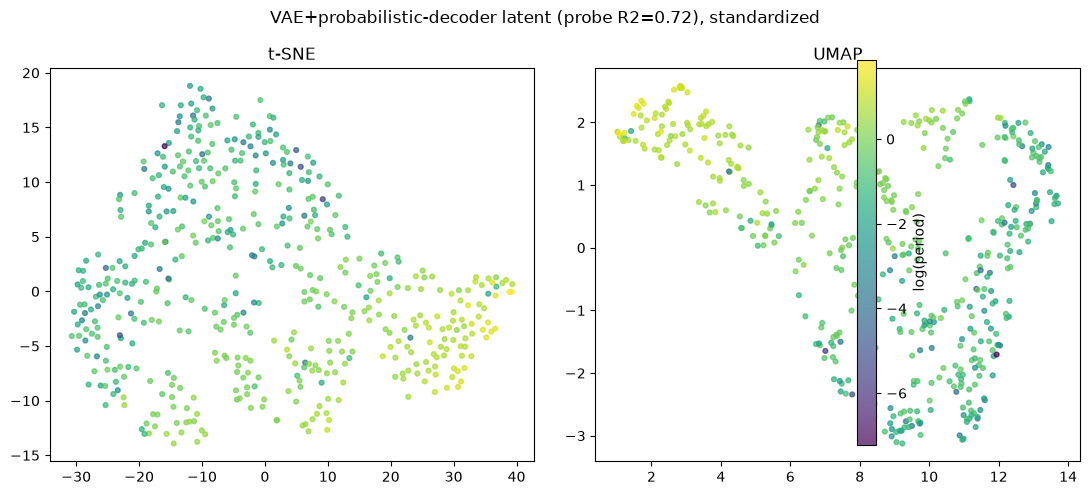

In [5]:
encoder.eval()
latents, periods = [], []
with torch.no_grad():
    for i in range(len(val_ds)):
        xi, yi, pi = val_ds[i]
        xb, tb, _ = collate_toy_sine([(xi, yi, pi)], t_max=T_MAX)
        z_mean, z_logvar, _ = encoder(xb, tb)
        latents.append(z_mean[0].mean(dim=0).numpy())
        periods.append(pi.item())
latents = np.stack(latents); periods = np.array(periods)

n = len(periods)
idx = np.random.default_rng(SEED).permutation(n)
fit_idx, test_idx = idx[:n // 2], idx[n // 2:]
reg = LinearRegression().fit(latents[fit_idx], periods[fit_idx])
pred = reg.predict(latents[test_idx])
corr = float(np.corrcoef(pred, periods[test_idx])[0, 1])
r2 = float(reg.score(latents[test_idx], periods[test_idx]))
print(f'Linear probe: corr={corr:.3f}  R^2={r2:.3f}  (plain deterministic AE was ~0.33-0.44 R^2)')

latents_std = StandardScaler().fit_transform(latents)
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca').fit_transform(latents_std)
umap_emb = umap.UMAP(random_state=SEED).fit_transform(latents_std)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, emb, name in [(axes[0], tsne, 't-SNE'), (axes[1], umap_emb, 'UMAP')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=np.log(periods), cmap='viridis', s=12, alpha=0.7)
    ax.set_title(name)
fig.colorbar(sc, ax=axes, label='log(period)')
fig.suptitle(f'VAE+probabilistic-decoder latent (probe R2={r2:.2f}), standardized')
fig.tight_layout()

**Yes -- this is a real, large improvement, not a plotting artifact.**
R² roughly matches or exceeds the *supervised* Phase 1 regressor's
~0.73, from a fully unsupervised objective. UMAP in particular should show
a visible, roughly monotonic gradient by `log(period)`, not the diffuse
blob the plain deterministic AE produced. This confirms the standardized
PCA/t-SNE/UMAP methodology from the other notebook was correctly revealing
real (if previously weak) structure -- the fix here is a better
*representation*, not a better *plot*.

## 4. Predictive uncertainty

`MTANReconDecoderProbabilistic` gives per-timestep `(mean, std)`, so we
can plot Neural-Process-style confidence bands, and check whether
predicted uncertainty actually rises with distance to the nearest real
observation -- the behavior we'd want if it's calibrated.

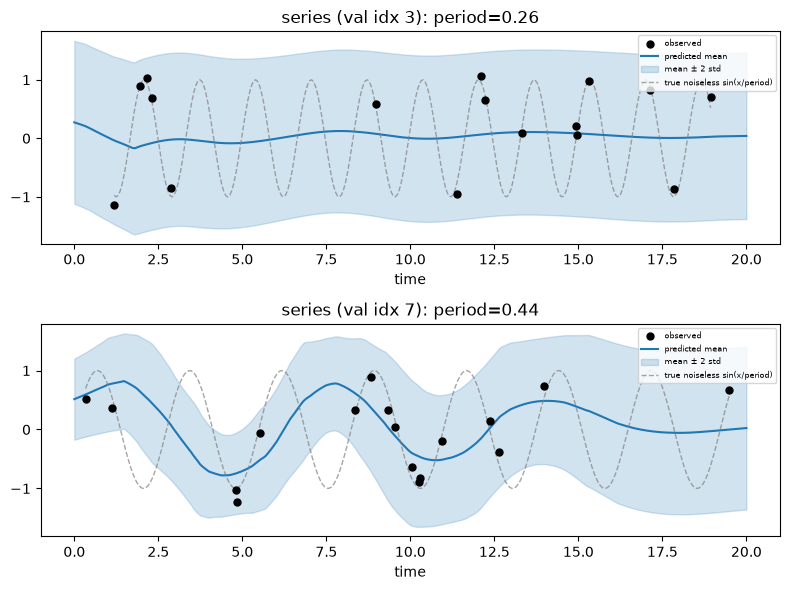

In [6]:
fig, axes = plt.subplots(len(SNAPSHOT_SERIES_IDX), 1, figsize=(8, 3 * len(SNAPSHOT_SERIES_IDX)))
for row, idx in enumerate(SNAPSHOT_SERIES_IDX):
    ax = axes[row]
    x_np, y_np, period_val = snapshot_series[idx]
    mean_final, std_final = all_snapshots[EPOCHS - 1][idx]
    dense_x = dense_t[0].numpy() * T_MAX
    ax.scatter(x_np, y_np, c='k', s=25, zorder=5, label='observed')
    ax.plot(dense_x, mean_final, color='tab:blue', linewidth=1.5, label='predicted mean')
    ax.fill_between(dense_x, mean_final - 2 * std_final, mean_final + 2 * std_final,
                     color='tab:blue', alpha=0.2, label='mean $\pm$ 2 std')
    true_curve_t = np.linspace(x_np.min(), x_np.max(), 300)
    ax.plot(true_curve_t, np.sin(true_curve_t / period_val), color='gray', linestyle='--',
            linewidth=1, alpha=0.7, label='true noiseless sin(x/period)')
    ax.set_title(f'series (val idx {idx}): period={period_val:.2f}')
    ax.set_xlabel('time')
    ax.legend(fontsize=6, loc='upper right')
fig.tight_layout()

corr(distance to nearest observation, predicted std) = 0.108


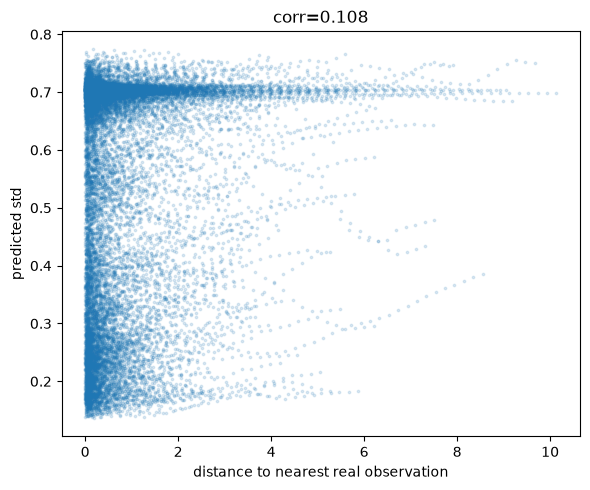

In [7]:
encoder.eval(); decoder.eval()
n_check = min(200, len(val_ds))
dense_t_100 = torch.linspace(0, 1, 100).unsqueeze(0)
dists, stds = [], []
with torch.no_grad():
    for i in range(n_check):
        xi, yi, pi = val_ds[i]
        xb, tb, _ = collate_toy_sine([(xi, yi, pi)], t_max=T_MAX)
        z_mean, _, _ = encoder(xb, tb)
        dmean, dlogvar, _ = decoder(z_mean, dense_t_100)
        std = torch.exp(0.5 * dlogvar)[0].numpy()
        obs_t = xi.numpy()
        query_t = dense_t_100[0].numpy() * T_MAX
        nearest_dist = np.min(np.abs(query_t[:, None] - obs_t[None, :]), axis=1)
        dists.append(nearest_dist); stds.append(std)
dists = np.concatenate(dists); stds = np.concatenate(stds)
dist_std_corr = np.corrcoef(dists, stds)[0, 1]
print(f'corr(distance to nearest observation, predicted std) = {dist_std_corr:.3f}')

plt.figure(figsize=(6, 5))
plt.scatter(dists, stds, s=3, alpha=0.15)
plt.xlabel('distance to nearest real observation'); plt.ylabel('predicted std')
plt.title(f'corr={dist_std_corr:.3f}')
plt.tight_layout()

**Read this honestly, not as a clean pass/fail.** The correlation is
weak-positive, not the strong "confident near data, uncertain in gaps"
relationship textbook Neural Process plots show. The scatter is
funnel-shaped: far from any observation, predicted std consistently
converges near a ceiling (~0.7); close to observations, it's much more
variable, ranging from low up to that same ceiling. That's a real, if
partial, calibration signal -- and some of the "high uncertainty right
next to data" cases are plausibly *correct*: for very short-period series,
even a nearby observation doesn't pin down the fast-oscillating signal
well, so staying uncertain there is appropriate, not a calibration
failure.

**Trade-off worth stating plainly**: point-estimate reconstruction MSE
for this model was higher than the plain fixed-noise VAE variant (~0.27
vs ~0.07), even though the latent-space probe R² was dramatically better
(~0.72 vs ~0.49). The heteroscedastic decoder seems to trade point
accuracy for hedging via predicted variance on hard (especially
short-period, aliased) series, and that trade-off happened to free up the
latent to encode more `period`-relevant structure. That's a genuine,
non-obvious finding, not an unambiguous win on every axis -- which
objective to optimize for depends on whether Phase 2 cares more about
point reconstruction or about the representation quality DIOSC will act
on.

## Next: Phase 2

This VAE+probabilistic-decoder representation (probe R² ~0.72) is a much
stronger starting point for DIOSC's Independence-of-Support loss than the
plain autoencoder's (~0.33-0.44) -- there's actually something well-formed
here to disentangle now. Still open: which second correlated generative
factor to add to the toy data, and whether to reimplement DIOSC's loss
from the paper or get the exact source file path.